# Multilingual Name Dataset — EDA

Exploratory analysis of `data/names.csv` — 2M deduplicated human entity names fetched from Wikidata,  
covering 9 scripts: **Latin (en), Cyrillic (ru), Arabic (ar), Han (zh), Kana/Kanji (ja), Hebrew (he), Devanagari (hi), Greek (el), Hangul (ko)**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
})
sns.set_palette('tab10')

In [2]:
df = pd.read_csv('../data/names.csv', low_memory=False)
print(f'Shape: {df.shape}')
df.head()

Shape: (2000000, 10)


,entity_id,name_en,name_ru,name_ar,name_zh,name_ja,name_he,name_hi,name_el,name_ko
0,Q10000001,Tatyana Kolotilshchikova,Татьяна Колотильщикова,NaN,NaN,タティアナ・コロティルシチコワ,NaN,NaN,Τατιάνα Κολατσίτσκοβα,NaN
1,Q1000002,Claus Hammel,NaN,NaN,C. 哈梅尔,NaN,NaN,NaN,Κλάους Χάμμελ,NaN
2,Q10000029,Nikolai Yuryev,Николай Петрович Юрьев,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Q1000005,Karel Matěj Čapek-Chod,Карел Матей Чапек-Ход,NaN,NaN,NaN,קרל מאטיי צ'אפק-חוד,NaN,NaN,NaN
4,Q1000006,Florian Eichinger,Флориан Эйчингер,NaN,弗洛里安·艾辛格,NaN,NaN,NaN,NaN,NaN


## 1. Coverage per Language
How many entities have a label in each script?

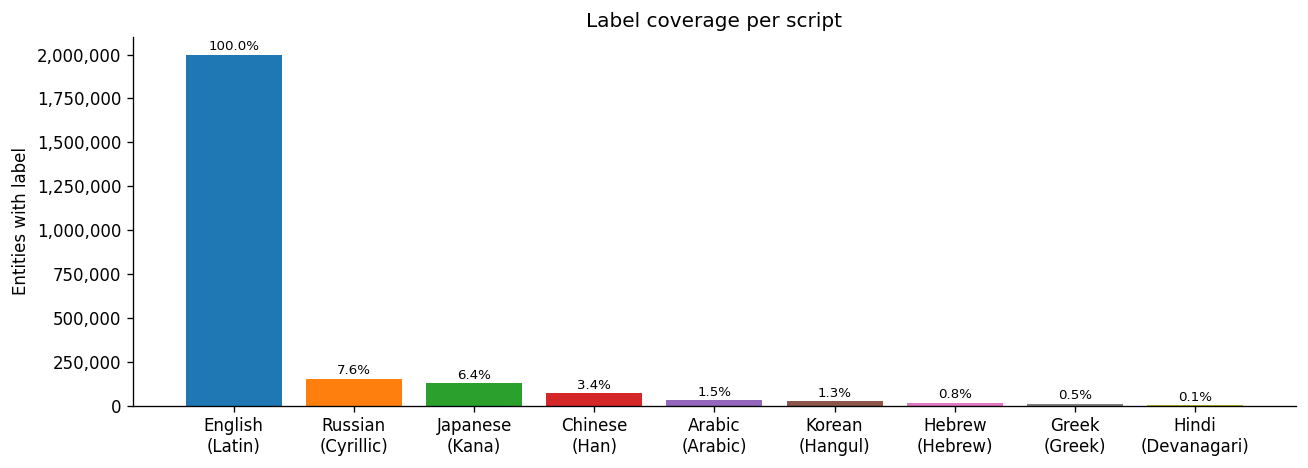

           count     pct
name_en  2000000  100.00
name_ru   152076    7.60
name_ja   127068    6.35
name_zh    68907    3.45
name_ar    30464    1.52
name_ko    25710    1.29
name_he    16170    0.81
name_el    10090    0.50
name_hi     2659    0.13


In [3]:
lang_cols = ['name_en','name_ru','name_ar','name_zh','name_ja','name_he','name_hi','name_el','name_ko']
script_labels = {
    'name_en': 'English\n(Latin)',
    'name_ru': 'Russian\n(Cyrillic)',
    'name_ar': 'Arabic\n(Arabic)',
    'name_zh': 'Chinese\n(Han)',
    'name_ja': 'Japanese\n(Kana)',
    'name_he': 'Hebrew\n(Hebrew)',
    'name_hi': 'Hindi\n(Devanagari)',
    'name_el': 'Greek\n(Greek)',
    'name_ko': 'Korean\n(Hangul)',
}

coverage = (df[lang_cols].notna() & (df[lang_cols] != '')).sum().sort_values(ascending=False)
coverage_pct = coverage / len(df) * 100

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar([script_labels[c] for c in coverage.index], coverage.values, color=sns.color_palette('tab10', 9))
for bar, pct in zip(bars, coverage_pct[coverage.index]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8000,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylabel('Entities with label')
ax.set_title('Label coverage per script')
plt.tight_layout()
plt.show()

print(coverage.to_frame('count').assign(pct=coverage_pct.round(2)))

## 2. Cross-Script Coverage
How many entities have labels in multiple scripts? This defines the pool of usable training pairs.

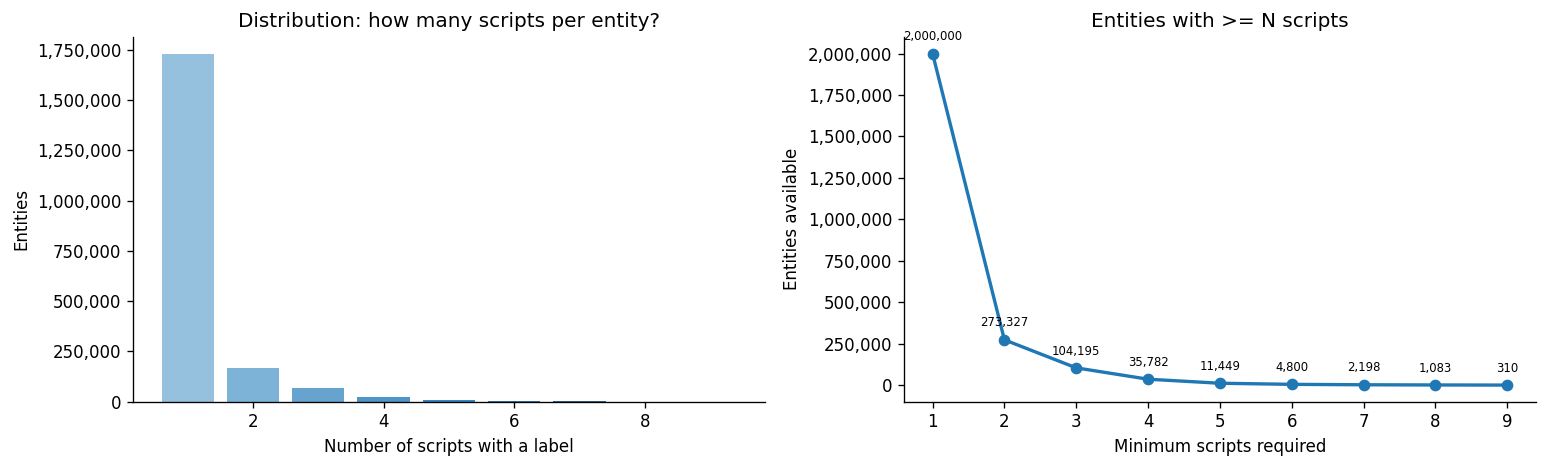

In [4]:
non_en_cols = [c for c in lang_cols if c != 'name_en']
filled = (df[lang_cols].notna() & (df[lang_cols] != ''))
df['n_scripts'] = filled.sum(axis=1)

script_counts = df['n_scripts'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution
axes[0].bar(script_counts.index, script_counts.values, color=sns.color_palette('Blues_d', len(script_counts)))
axes[0].set_xlabel('Number of scripts with a label')
axes[0].set_ylabel('Entities')
axes[0].set_title('Distribution: how many scripts per entity?')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Cumulative: entities with >= N scripts
thresholds = range(1, 10)
counts_ge = [(df['n_scripts'] >= t).sum() for t in thresholds]
axes[1].plot(list(thresholds), counts_ge, marker='o', linewidth=2)
axes[1].set_xlabel('Minimum scripts required')
axes[1].set_ylabel('Entities available')
axes[1].set_title('Entities with >= N scripts')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].set_xticks(list(thresholds))
for t, c in zip(thresholds, counts_ge):
    axes[1].annotate(f'{c:,}', (t, c), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=7)

plt.tight_layout()
plt.show()

## 3. Pairwise Script Co-occurrence
Which script pairs most often co-occur on the same entity? This tells us which pairs will yield the most training examples.

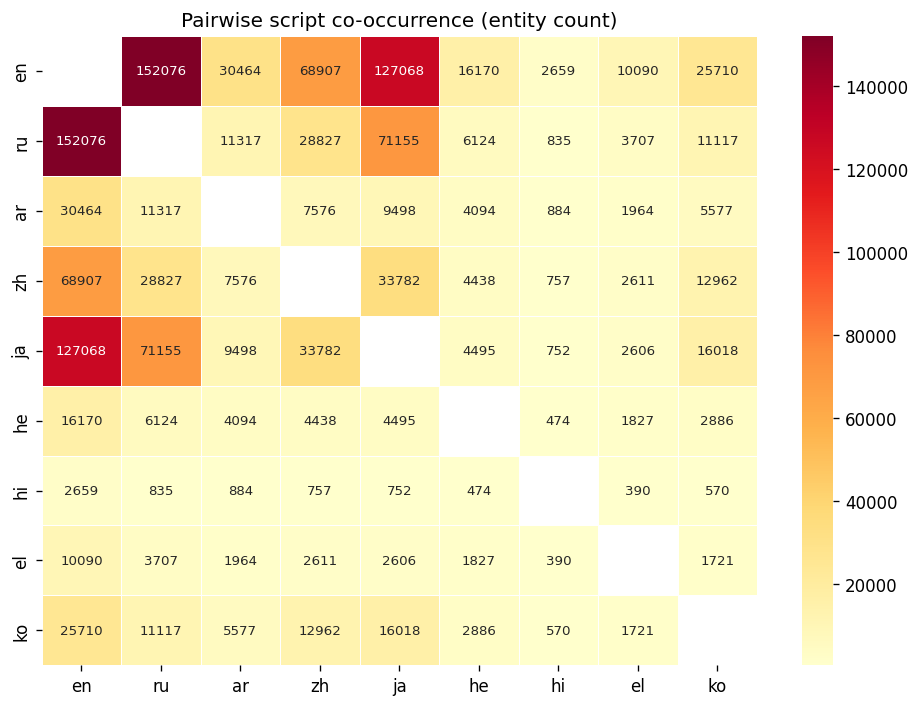

In [5]:
short = {'name_en':'en','name_ru':'ru','name_ar':'ar','name_zh':'zh',
         'name_ja':'ja','name_he':'he','name_hi':'hi','name_el':'el','name_ko':'ko'}

cooc = pd.DataFrame(index=[short[c] for c in lang_cols], columns=[short[c] for c in lang_cols], dtype=float)
for c1 in lang_cols:
    for c2 in lang_cols:
        has_both = filled[c1] & filled[c2]
        cooc.loc[short[c1], short[c2]] = has_both.sum()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.eye(len(lang_cols), dtype=bool)  # hide diagonal
sns.heatmap(cooc.astype(float), annot=True, fmt='.0f', cmap='YlOrRd',
            mask=mask, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Pairwise script co-occurrence (entity count)')
plt.tight_layout()
plt.show()

## 4. Name Length Distribution
Byte length and character length across scripts — important for model input sizing.

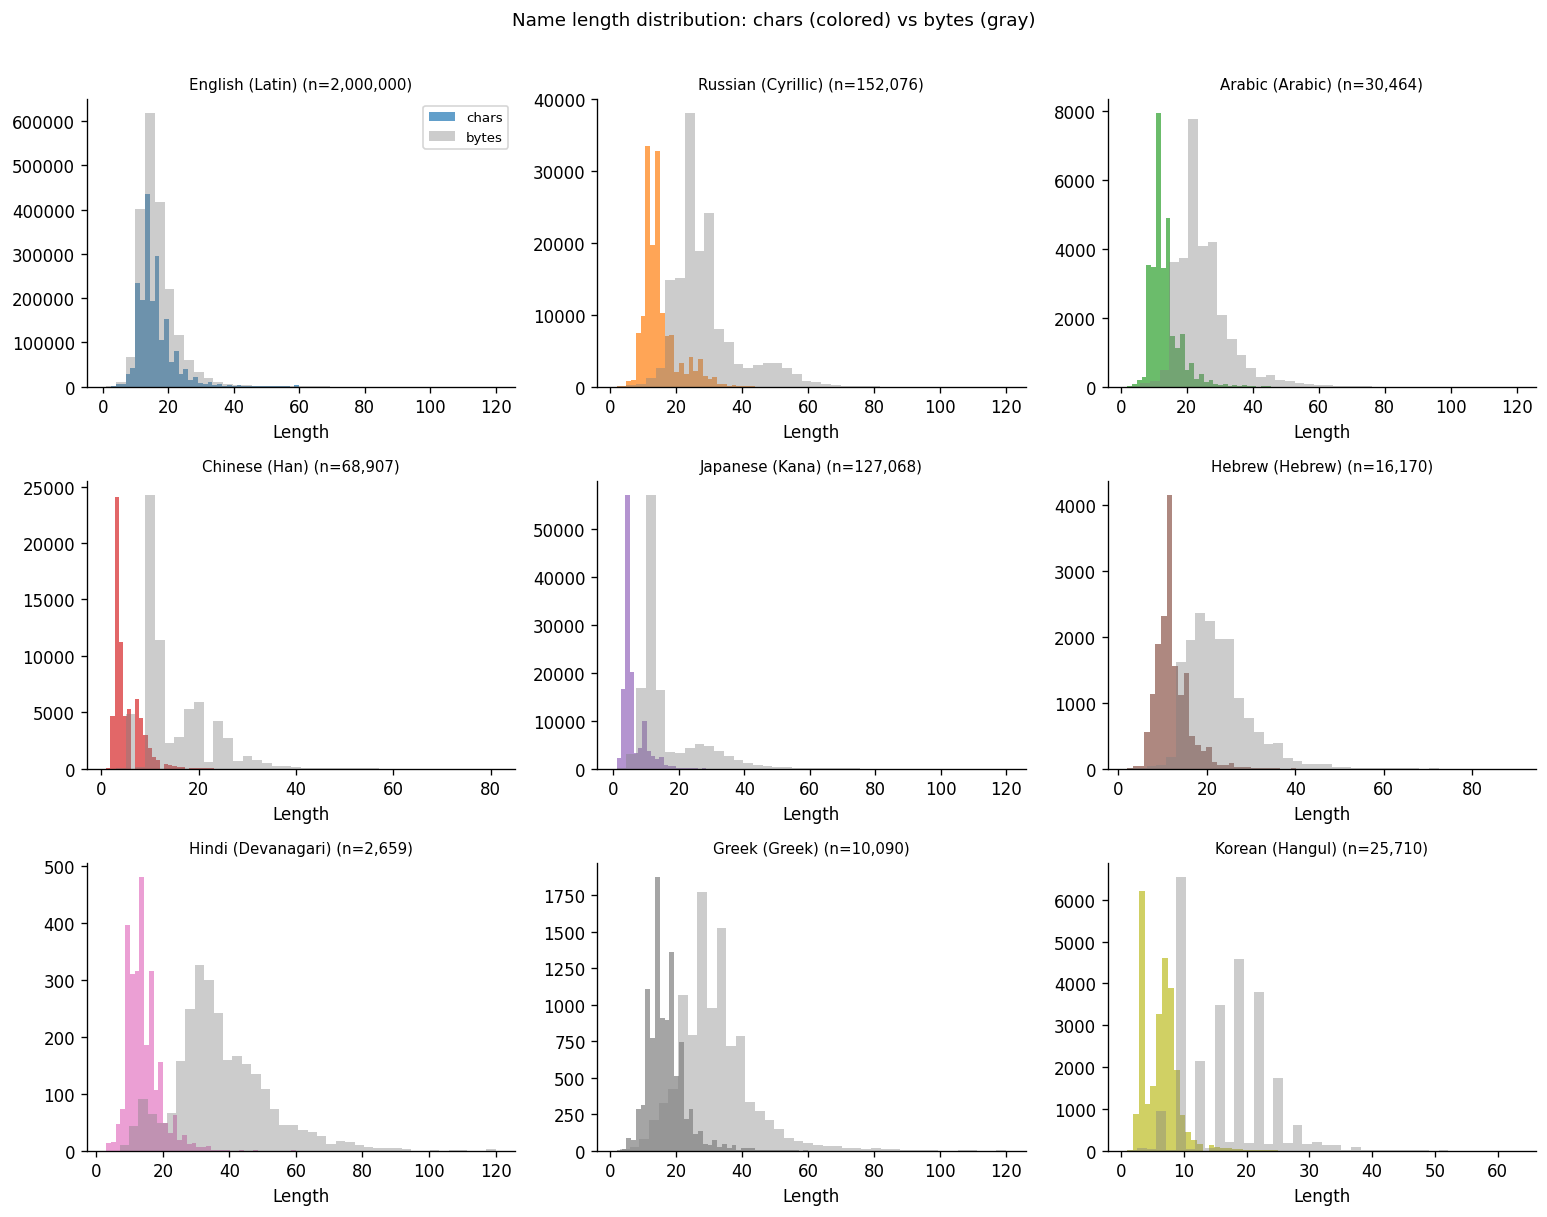

,n,mean_chars,median_chars,mean_bytes,p95_bytes
en,2000000.0,16.0,15.0,16.3,27.0
ru,152076.0,15.1,14.0,28.8,52.0
ar,30464.0,13.4,12.0,25.1,40.0
zh,68907.0,5.1,4.0,14.4,29.0
ja,127068.0,5.7,4.0,16.7,36.0
he,16170.0,12.2,11.0,22.8,36.0
hi,2659.0,14.1,13.0,37.6,64.0
el,10090.0,16.9,16.0,31.9,51.0
ko,25710.0,6.2,6.0,16.6,28.0


In [7]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10), sharey=False)
axes = axes.flatten()
colors = sns.color_palette('tab10', 9)

for i, (col, color) in enumerate(zip(lang_cols, colors)):
    subset = df[col].dropna()
    subset = subset[subset != '']
    char_lens = subset.str.len()
    byte_lens = subset.apply(lambda x: len(x.encode('utf-8')))
    ax = axes[i]
    ax.hist(char_lens.clip(upper=60), bins=40, alpha=0.7, color=color, label='chars')
    ax.hist(byte_lens.clip(upper=120), bins=40, alpha=0.4, color='gray', label='bytes')
    ax.set_title(f'{script_labels[col].replace(chr(10)," ")} (n={len(subset):,})', fontsize=9)
    ax.set_xlabel('Length')
    if i == 0: ax.legend(fontsize=8)

plt.suptitle('Name length distribution: chars (colored) vs bytes (gray)', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

# Summary table
stats = {}
for col in lang_cols:
    s = df[col].dropna()
    s = s[s != '']
    stats[short[col]] = {
        'n': len(s),
        'mean_chars': s.str.len().mean(),
        'median_chars': s.str.len().median(),
        'mean_bytes': s.apply(lambda x: len(x.encode('utf-8'))).mean(),
        'p95_bytes': s.apply(lambda x: len(x.encode('utf-8'))).quantile(0.95),
    }
pd.DataFrame(stats).T.round(1)

## 5. Token Count Estimate
Estimated number of byte-level tokens per name (bytes / 1). Also shows bytes-per-character ratio — proxy for encoding overhead.

/tmp/ipykernel_38149/2489099300.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ratio_df, x='script', y='bytes_per_char', order=order, palette='tab10', ax=ax, flierprops=dict(marker='.', alpha=0.1))


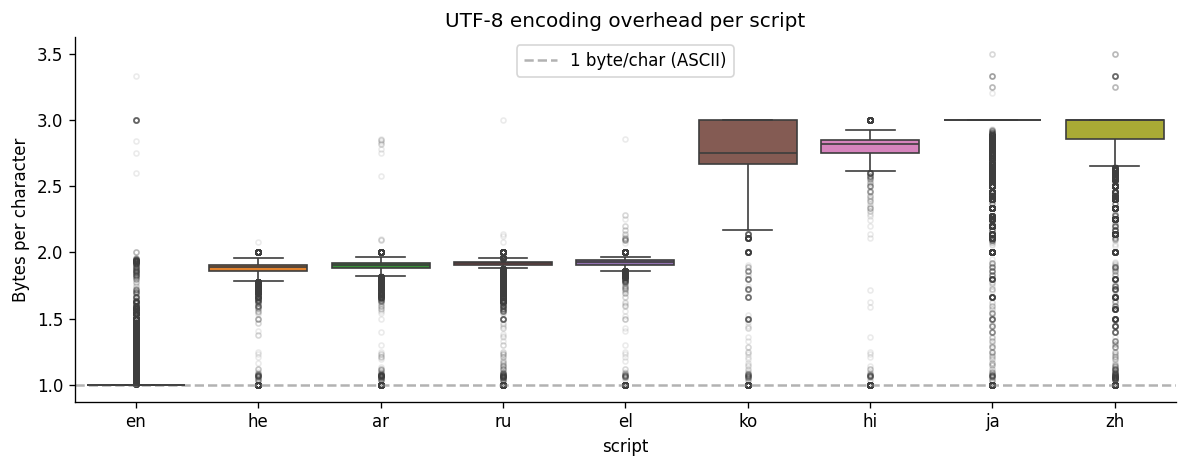

In [8]:
ratio_data = []
for col in lang_cols:
    s = df[col].dropna()
    s = s[s != '']
    ratios = s.apply(lambda x: len(x.encode('utf-8')) / max(len(x), 1))
    for r in ratios:
        ratio_data.append({'script': short[col], 'bytes_per_char': r})

ratio_df = pd.DataFrame(ratio_data)

fig, ax = plt.subplots(figsize=(10, 4))
order = ratio_df.groupby('script')['bytes_per_char'].median().sort_values().index
sns.boxplot(data=ratio_df, x='script', y='bytes_per_char', order=order, palette='tab10', ax=ax, flierprops=dict(marker='.', alpha=0.1))
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.6, label='1 byte/char (ASCII)')
ax.set_ylabel('Bytes per character')
ax.set_title('UTF-8 encoding overhead per script')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Most Common Name Tokens
Top first-name tokens in English — quick sanity check on data quality.

/tmp/ipykernel_38149/3526946109.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_first.index, rotation=45, ha='right', fontsize=9)


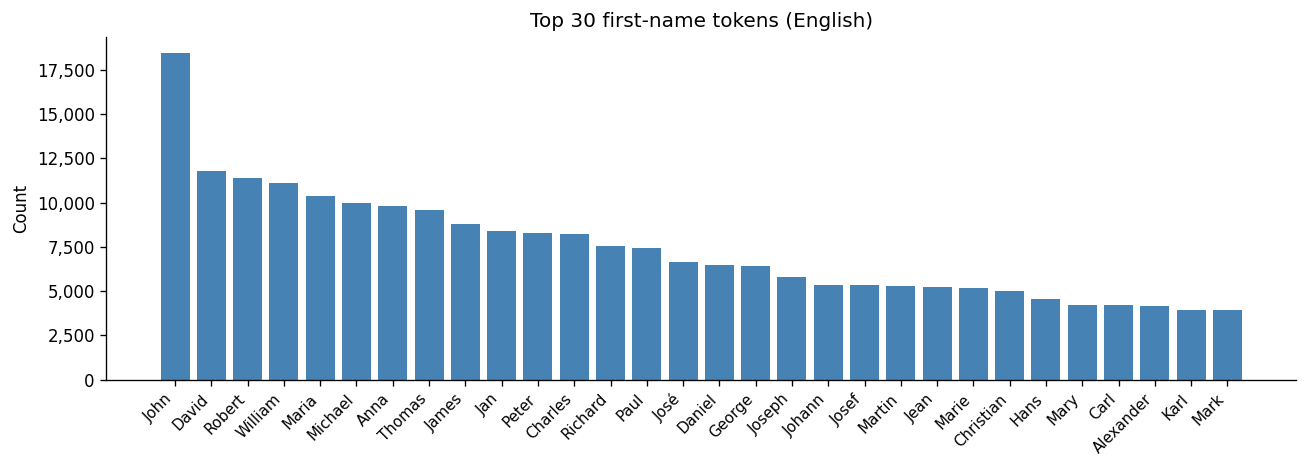

In [9]:
first_tokens = df['name_en'].dropna().str.split().str[0]
top_first = first_tokens.value_counts().head(30)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(top_first.index, top_first.values, color='steelblue')
ax.set_xticklabels(top_first.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Count')
ax.set_title('Top 30 first-name tokens (English)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 7. Name Token Count (word count)
How many words per name? Relevant for deciding how to chunk/truncate inputs.

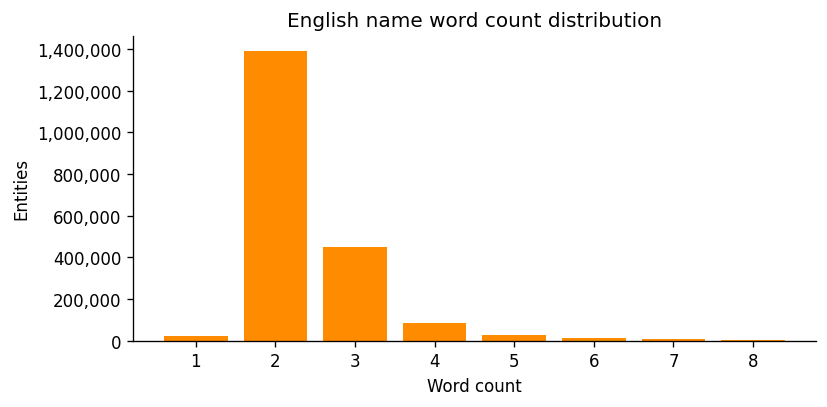

           count    pct
name_en                
1          22069   1.10
2        1393782  69.69
3         448629  22.43
4          86091   4.30
5          25781   1.29
6          10608   0.53
7           5803   0.29
8           3044   0.15


In [10]:
word_counts = df['name_en'].dropna().str.split().str.len().value_counts().sort_index()
word_counts = word_counts[word_counts.index <= 8]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(word_counts.index.astype(str), word_counts.values, color='darkorange')
ax.set_xlabel('Word count')
ax.set_ylabel('Entities')
ax.set_title('English name word count distribution')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print(word_counts.to_frame('count').assign(pct=(word_counts/len(df)*100).round(2)))

## 8. Sample Rows
Quick sanity check — entities with labels in the most scripts.

In [11]:
df.sort_values('n_scripts', ascending=False)[lang_cols + ['n_scripts']].head(20)

,name_en,name_ru,name_ar,name_zh,name_ja,name_he,name_hi,name_el,name_ko,n_scripts
599778,Jonathan Eric Gustafson,Jonathan Eric Gustafson,Jonathan Eric Gustafson,Jonathan Eric Gustafson,Jonathan Eric Gustafson,Jonathan Eric Gustafson,Jonathan Eric Gustafson,Jonathan Eric Gustafson,조너선 거스터프슨,9
743272,Ranbir Kapoor,Ранбир Капур,رانبير كابور,兰比尔·卡普尔,ランビール・カプール,רנביר קאפור,रणबीर कपूर,Ρανμπίρ Καπούρ,란비르 카푸르,9
505476,Carl Linnaeus,Карл Линней,كارولوس لينيوس,卡尔·林奈,カール・フォン・リンネ,קארולוס לינאוס,कार्ल लीनियस,Κάρολος Λινναίος,칼 폰 린네,9
377762,Paul Samuelson,Пол Энтони Самуэльсон,بول سامويلسون,保羅·安東尼·薩繆爾森,ポール・サミュエルソン,פול סמואלסון,पाल एन्थनी सेमुएल्सन,Πολ Σάμιουελσον,폴 새뮤얼슨,9
1815057,Ibrahim Traoré,Ибраим Траоре,إبراهيم تراوري,易卜拉欣·特拉奧雷,イブラヒム・トラオレ,איברהים טראורה,इब्राहिम ट्रोरे,Ιμπραήμ Τραορέ,이브라힘 트라오레,9
832534,Daniel Berlinski,Daniel Berlinski,Daniel Berlinski,Daniel Berlinski,Daniel Berlinski,Daniel Berlinski,Daniel Berlinski,Daniel Berlinski,Daniel Berlinski,9
449978,Jennifer Connelly,Дженнифер Коннелли,جنيفر كونلي,珍妮佛·康納莉,ジェニファー・コネリー,ג'ניפר קונלי,जेनिफ़र कोनेली,Τζένιφερ Κόνελι,제니퍼 코널리,9
1970182,Emma Myers,Эмма Майерс,إيما مايرز,愛瑪·梅耶斯,エマ・マイヤーズ,אמה מאיירס,एम्मा मायर्स,Έμμα Μάιερς,에마 마이어스,9
379358,Jaroslav Seifert,Ярослав Сейферт,ياروسلاف سيفرت,雅罗斯拉夫·塞弗尔特,ヤロスラフ・サイフェルト,ירוסלב סיפרט,यारोस्लाव सैफर्ट,Γιάροσλαβ Σάιφερτ,야로슬라프 사이페르트,9
726291,Khalifa bin Zayed Al Nahyan,Халифа ибн Зайд аль-Нахайян,خليفة بن زايد آل نهيان,哈利法·本·扎耶德·阿勒纳哈扬,ハリーファ・ビン・ザーイド・アール・ナヒヤーン,ח'ליפה בן זאיד אאל נהיאן,खलीफा बिन जायद अल नाहयान,Χαλίφα μπιν Ζαγέντ αλ Ναχαγιάν,칼리파 빈 자이드 알 나얀,9


## 9. Usable Training Pairs Estimate
Conservative estimate of cross-script pairs available for contrastive training (en paired with each other script).

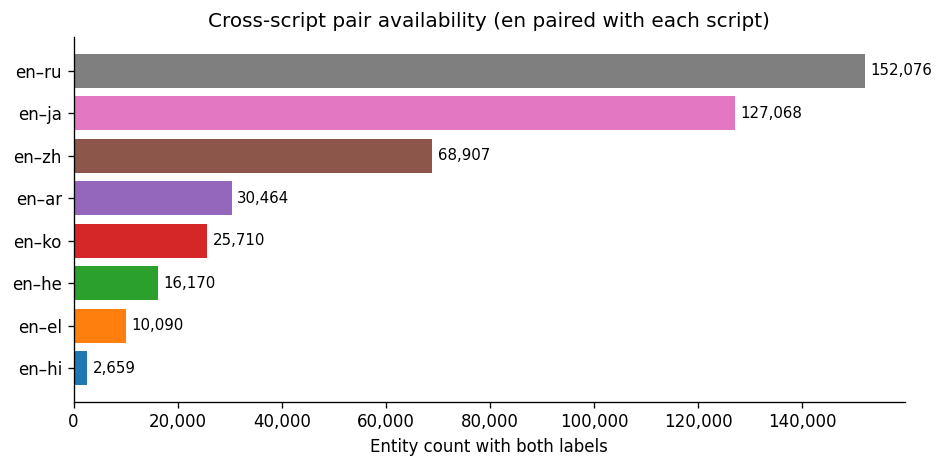

Total cross-script pairs (en + at least one other): 273,327
Total pairs summed across all en–X combinations: 433,144


In [12]:
pair_counts = {}
for col in non_en_cols:
    has_both = filled['name_en'] & filled[col]
    pair_counts[f'en–{short[col]}'] = has_both.sum()

pair_series = pd.Series(pair_counts).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(pair_series.index, pair_series.values, color=sns.color_palette('tab10', len(pair_series)))
for bar, v in zip(bars, pair_series.values):
    ax.text(v + 1000, bar.get_y() + bar.get_height()/2, f'{v:,}', va='center', fontsize=9)
ax.set_xlabel('Entity count with both labels')
ax.set_title('Cross-script pair availability (en paired with each script)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print(f'Total cross-script pairs (en + at least one other): {(df["n_scripts"] >= 2).sum():,}')
print(f'Total pairs summed across all en–X combinations: {pair_series.sum():,}')